In [17]:
from seeq import spy
spy.jobs.schedule("every day at 8:05 AM")


[spy.jobs MOCK] schedule('every day at 8:05 AM') — ignorado localmente


# 05 - Analise de Trocas do Maintacker
**Objetivo:** cruzar os resets de `target_rul` com as datas confirmadas em `troca_modulo.csv` para:
1. Confirmar quais resets foram **troca do maintacker** vs **ajuste de adesivo**
2. Calcular a duracao de cada ciclo e identificar trocas prematuras (ciclo curto)
3. Identificar os casos **Ta Ferrando com meu LPLCC** - trocas antes do ciclo tipico


In [18]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.1f}'.format)

## 1. Carregar hour_prev.csv e detectar resets de `target_rul`

In [19]:
df = pd.read_csv('00_hour_prev.csv')
df['ts'] = pd.to_datetime(df['Timestamp'])
df['rul'] = pd.to_numeric(df['target_rul'], errors='coerce')
df = df.sort_values('ts').reset_index(drop=True)
df['is_reset'] = df['rul'].diff() > 0
reset_idx = df[df['is_reset']].index

events = []
for idx in reset_idx:
    prev = idx - 1
    if prev < 0:
        continue
    events.append({
        'ts_ultimo'          : df.loc[prev, 'ts'],
        'ts_primeiro'        : df.loc[idx,  'ts'],
        'target_rul_restante': round(df.loc[prev, 'rul'], 2),
        'novo_rul_inicial'   : round(df.loc[idx,  'rul'], 2),
    })

swaps = pd.DataFrame(events)
swaps['data_troca'] = pd.to_datetime(swaps['ts_ultimo'].dt.strftime('%Y-%m-%d'))

# Duracao de cada ciclo (horas entre ts_primeiro do swap anterior e ts_ultimo deste)
duracoes = [float('nan')]
for i in range(1, len(swaps)):
    dur = (swaps.loc[i, 'ts_ultimo'] - swaps.loc[i-1, 'ts_primeiro']).total_seconds() / 3600
    duracoes.append(round(dur, 2))
swaps['cycle_duration_h'] = duracoes

print(f'Resets detectados: {len(swaps)}')
swaps.head(10)


Resets detectados: 9


,ts_ultimo,ts_primeiro,target_rul_restante,novo_rul_inicial,data_troca,cycle_duration_h
0,2022-07-12 19:49:01-03:00,2022-07-13 03:06:00-03:00,1.2,2393.9,2022-07-12,NaN
1,2022-10-20 19:03:01-03:00,2022-10-21 03:18:48-03:00,1.9,2609.7,2022-10-20,2391.9
2,2023-02-06 11:14:01-03:00,2023-02-07 03:06:01-03:00,9.8,2945.9,2023-02-06,2599.9
3,2023-06-09 16:45:59-03:00,2023-06-10 03:16:01-03:00,4.2,209.7,2023-06-09,2941.7
4,2023-06-18 19:18:40-03:00,2023-06-19 03:02:45-03:00,1.7,1530.0,2023-06-18,208.0
5,2023-08-21 12:20:01-03:00,2023-08-22 04:59:12-03:00,8.7,2584.0,2023-08-21,1521.3
6,2023-12-07 20:59:37-03:00,2023-12-08 04:56:01-03:00,0.0,6064.1,2023-12-07,2584.0
7,2024-08-16 20:21:02-03:00,2024-08-17 00:40:01-03:00,0.7,8612.3,2024-08-16,6063.4
8,2025-08-10 19:35:06-03:00,2025-08-11 03:58:01-03:00,1.4,2513.0,2025-08-10,8610.9


## 2. Carregar troca_modulo.csv — datas confirmadas de troca


In [20]:
tc = pd.read_csv('troca_modulo.csv', encoding='utf-8-sig')
tc['Date'] = pd.to_datetime(tc.iloc[:, 0]).dt.tz_localize(None).dt.normalize()
trocas_confirmadas = tc[['Date']].copy()
trocas_confirmadas['tipo_obs'] = 'Troca'

print(f'Trocas confirmadas carregadas: {len(trocas_confirmadas)}')
print(trocas_confirmadas.to_string(index=False))


Trocas confirmadas carregadas: 13
      Date tipo_obs
2022-06-08    Troca
2022-07-13    Troca
2022-10-21    Troca
2023-02-07    Troca
2023-02-23    Troca
2023-06-10    Troca
2023-08-22    Troca
2023-09-26    Troca
2023-12-08    Troca
2024-08-17    Troca
2025-03-13    Troca
2025-08-11    Troca
2025-11-24    Troca


## 3. Cruzamento: reset no modelo ↔ troca confirmada no troca_modulo.csv
Janela de tolerância: **±3 dias**.


In [21]:
TOLERANCIA_DIAS = 3

def busca_troca_confirmada(data_reset, df_trocas, tolerancia_dias=TOLERANCIA_DIAS):
    delta = (df_trocas['Date'] - data_reset).abs().dt.days
    idx_min = delta.idxmin()
    if delta[idx_min] <= tolerancia_dias:
        return df_trocas.loc[idx_min]
    return None

swaps['confirmado_troca'] = False
swaps['delta_dias_troca'] = np.nan

for i, row in swaps.iterrows():
    match = busca_troca_confirmada(row['data_troca'], trocas_confirmadas)
    if match is not None:
        swaps.at[i, 'confirmado_troca'] = True
        swaps.at[i, 'delta_dias_troca'] = abs((match['Date'] - row['data_troca']).days)

print(f'Resets com troca confirmada: {swaps["confirmado_troca"].sum()}')
print(f'Resets sem correspondencia : {(~swaps["confirmado_troca"]).sum()}')


Resets com troca confirmada: 8
Resets sem correspondencia : 1


## 4. Classificação final de cada reset

In [22]:
ciclos_validos = swaps['cycle_duration_h'].dropna()
LIMIAR_DURACAO_H = float(np.percentile(ciclos_validos, 33))

def classifica_reset(row):
    if row['confirmado_troca']:
        if pd.notna(row['cycle_duration_h']) and row['cycle_duration_h'] < LIMIAR_DURACAO_H:
            return 'Troca Prematura (Ta Ferrando!)'
        else:
            return 'Troca Confirmada - ciclo completo'
    else:
        return 'Possivel Ajuste de Adesivo'

swaps['classificacao'] = swaps.apply(classifica_reset, axis=1)
print(f'Limiar duracao P33: {LIMIAR_DURACAO_H:.0f}h  ({LIMIAR_DURACAO_H/24:.1f} dias)')
print(swaps['classificacao'].value_counts().to_string())


Limiar duracao P33: 2451h  (102.1 dias)
classificacao
Troca Confirmada - ciclo completo    6
Troca Prematura (Ta Ferrando!)       2
Possivel Ajuste de Adesivo           1


## 5. DataFrame principal — storytelling de cada evento

In [23]:
story = swaps[[
    'ts_ultimo', 'target_rul_restante', 'cycle_duration_h',
    'novo_rul_inicial', 'classificacao'
]].copy()
story.columns = [
    'Timestamp da Troca', 'RUL Restante (h)', 'Duracao do Ciclo (h)',
    'Vida Inicial Novo (h)', 'Classificacao'
]
story = story.sort_values('Timestamp da Troca', ascending=False).reset_index(drop=True)
display(story)


,Timestamp da Troca,RUL Restante (h),Duracao do Ciclo (h),Vida Inicial Novo (h),Classificacao
0,2025-08-10 19:35:06-03:00,1.4,8610.9,2513.0,Troca Confirmada - ciclo completo
1,2024-08-16 20:21:02-03:00,0.7,6063.4,8612.3,Troca Confirmada - ciclo completo
2,2023-12-07 20:59:37-03:00,0.0,2584.0,6064.1,Troca Confirmada - ciclo completo
3,2023-08-21 12:20:01-03:00,8.7,1521.3,2584.0,Troca Prematura (Ta Ferrando!)
4,2023-06-18 19:18:40-03:00,1.7,208.0,1530.0,Possivel Ajuste de Adesivo
5,2023-06-09 16:45:59-03:00,4.2,2941.7,209.7,Troca Confirmada - ciclo completo
6,2023-02-06 11:14:01-03:00,9.8,2599.9,2945.9,Troca Confirmada - ciclo completo
7,2022-10-20 19:03:01-03:00,1.9,2391.9,2609.7,Troca Prematura (Ta Ferrando!)
8,2022-07-12 19:49:01-03:00,1.2,NaN,2393.9,Troca Confirmada - ciclo completo


## 6. Foco: casos "Ta Ferrando com meu LPLCC 🔴"
Trocas confirmadas em que o modelo ainda previa vida útil significativa.

In [24]:
ferrando = swaps[
    swaps['classificacao'].str.startswith('Troca Prematura')
][['ts_ultimo', 'target_rul_restante', 'cycle_duration_h']].copy()
ferrando = ferrando.sort_values('cycle_duration_h').reset_index(drop=True)
ferrando.columns = ['Data da Troca', 'RUL Restante (h)', 'Duracao do Ciclo (h)']
print(f'Total de trocas prematuras: {len(ferrando)}')
print(f'Duracao media dos prematuros: {ferrando["Duracao do Ciclo (h)"].mean():.0f}h')
display(ferrando)


Total de trocas prematuras: 2
Duracao media dos prematuros: 1957h


,Data da Troca,RUL Restante (h),Duracao do Ciclo (h)
0,2023-08-21 12:20:01-03:00,8.7,1521.3
1,2022-10-20 19:03:01-03:00,1.9,2391.9


In [25]:
story['Classificacao'].unique()

<StringArray>
['Troca Confirmada - ciclo completo',    'Troca Prematura (Ta Ferrando!)',
        'Possivel Ajuste de Adesivo']
Length: 3, dtype: str

## 7. Linha do tempo completa — target_rul + eventos marcados

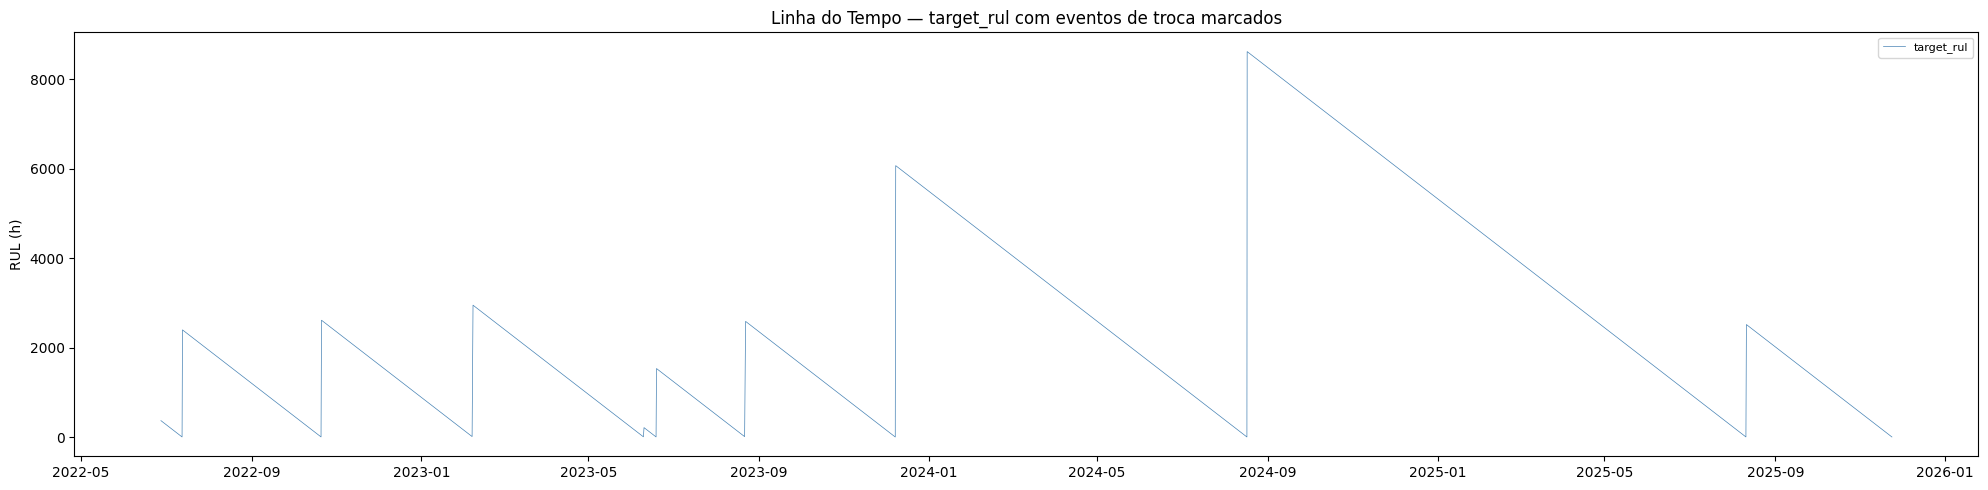

In [26]:
fig, ax = plt.subplots(figsize=(20, 5))

ax.plot(df['ts'], df['rul'], lw=0.5, color='steelblue', label='target_rul')

cores = {
    '✅ Troca Confirmada — vida esgotada'   : ('green',  'o', 60),
    '🔴 Troca Prematura (Ta Ferrando!)'     : ('red',    '*', 120),
    '🟡 Possível Ajuste de Adesivo'         : ('orange', 's', 40),
}

for label, (cor, marcador, tamanho) in cores.items():
    subset = swaps[swaps['classificacao'] == label]
    if subset.empty:
        continue
    # posicionar marcador na última leitura do maintacker antigo
    ys = []
    for _, row in subset.iterrows():
        match = df[df['ts'] == row['ts_ultimo']]
        ys.append(match['rul'].values[0] if len(match) else 0)
    ax.scatter(subset['ts_ultimo'], ys,
               color=cor, marker=marcador, s=tamanho, label=label, zorder=5)

ax.set_title('Linha do Tempo — target_rul com eventos de troca marcados')
ax.set_ylabel('RUL (h)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('swap_timeline.png', dpi=120)
plt.show()

## 8. Quanto de vida útil foi descartada por classificação?

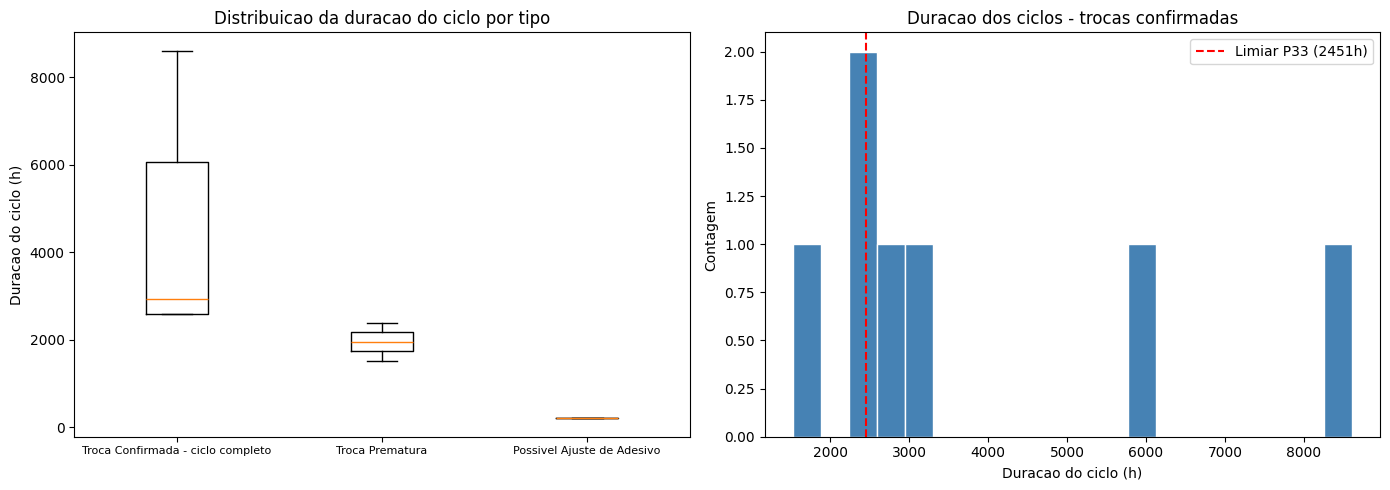

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

groups, labels = [], []
for label in swaps['classificacao'].unique():
    vals = swaps[swaps['classificacao'] == label]['cycle_duration_h'].dropna().values
    if len(vals):
        groups.append(vals)
        labels.append(label.split('(')[0].strip()[:35])

axes[0].boxplot(groups, tick_labels=labels, vert=True)
axes[0].set_title('Distribuicao da duracao do ciclo por tipo')
axes[0].set_ylabel('Duracao do ciclo (h)')
axes[0].tick_params(axis='x', labelsize=8)

confirmadas = swaps[swaps['confirmado_troca']]
axes[1].hist(confirmadas['cycle_duration_h'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(LIMIAR_DURACAO_H, color='red', ls='--', label=f'Limiar P33 ({LIMIAR_DURACAO_H:.0f}h)')
axes[1].set_title('Duracao dos ciclos - trocas confirmadas')
axes[1].set_xlabel('Duracao do ciclo (h)')
axes[1].set_ylabel('Contagem')
axes[1].legend()

plt.tight_layout()
plt.savefig('swap_cycle_distribution.png', dpi=120)
plt.show()


## 9. Zoom — apenas eventos de 2026 (período do Excel)

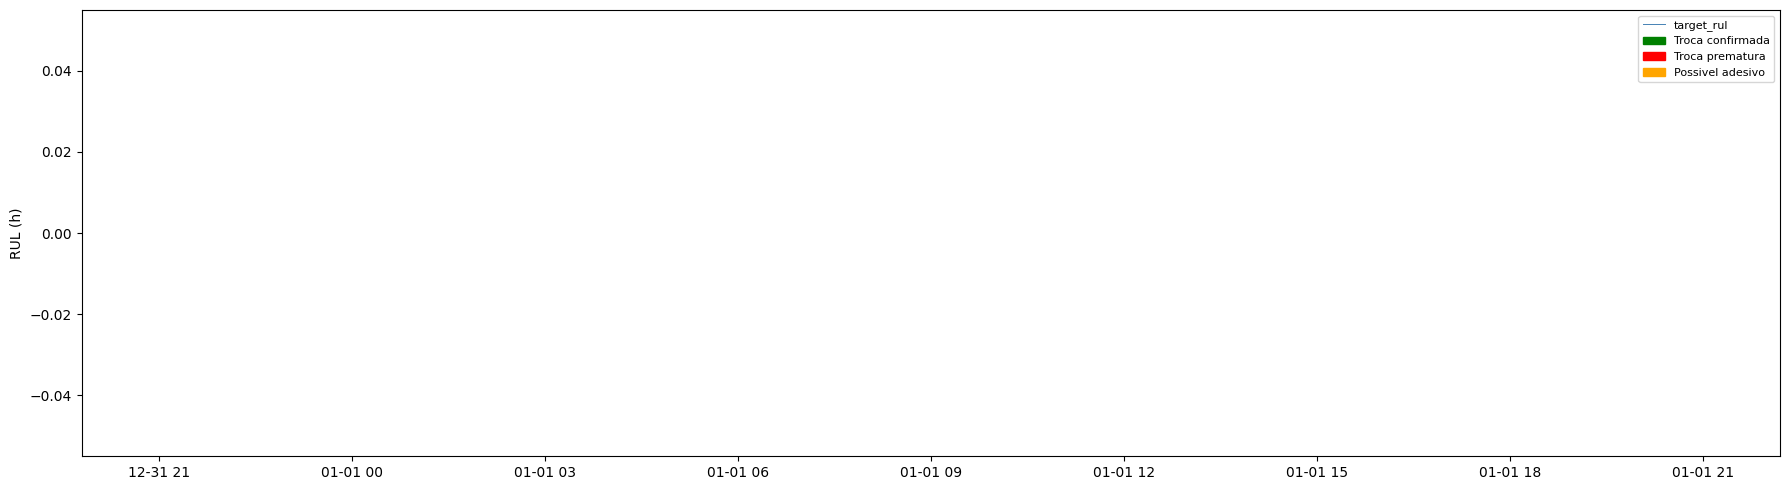

In [28]:
ANO_FOCO = 2026
swaps_ano = swaps[swaps['ts_ultimo'].dt.year == ANO_FOCO].copy()
df_ano    = df[df['ts'].dt.year == ANO_FOCO]

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df_ano['ts'], df_ano['rul'], lw=0.7, color='steelblue', label='target_rul')

for _, row in swaps_ano.iterrows():
    cor = 'red'    if 'Prematura' in row['classificacao'] else \
          'green'  if 'Confirmada' in row['classificacao'] else 'orange'
    ax.axvline(row['ts_ultimo'], color=cor, alpha=0.4, lw=1.5)
    dur_label = f"{row['cycle_duration_h']:.0f}h" if pd.notna(row['cycle_duration_h']) else '?'
    ax.annotate(
        f"{dur_label}\n({row['classificacao'][:2]})",
        xy=(row['ts_ultimo'], row['target_rul_restante']),
        fontsize=7, ha='center', va='bottom', color=cor,
        xytext=(0, 12), textcoords='offset points'
    )

verde_patch = mpatches.Patch(color='green',  label='Troca confirmada')
verm_patch  = mpatches.Patch(color='red',    label='Troca prematura')
lar_patch   = mpatches.Patch(color='orange', label='Possivel adesivo')
handles, lbls = ax.get_legend_handles_labels()
ax.legend(handles=handles + [verde_patch, verm_patch, lar_patch], fontsize=8)
ax.set_ylabel('RUL (h)')
plt.tight_layout()
plt.savefig(f'swap_zoom_{ANO_FOCO}.png', dpi=120)
plt.show()


## 10. Exportar dataset enriquecido
Salva `hour_prev.csv` com coluna `evento_troca` (checklist item 2.3).

In [29]:
# Marcar cada linha de df com o tipo de evento de troca mais próximo
df['evento_troca'] = 'Normal'

for _, row in swaps.iterrows():
    # janela de ±8h ao redor do timestamp de troca
    janela = pd.Timedelta('8h')
    mask = (df['ts'] >= row['ts_ultimo'] - janela) & (df['ts'] <= row['ts_ultimo'] + janela)
    if '🔴' in row['classificacao']:
        df.loc[mask, 'evento_troca'] = 'Troca_Prematura'
    elif '✅' in row['classificacao']:
        df.loc[mask, 'evento_troca'] = 'Troca_Confirmada'
    elif '🟡' in row['classificacao']:
        df.loc[mask, 'evento_troca'] = 'Possivel_Adesivo'

print(df['evento_troca'].value_counts().to_string())
df.drop(columns=['ts', 'rul', 'is_reset']).to_csv('05_swap_analysis.csv', index=False)
print('\nSalvo: hour_prev_com_eventos.csv')

evento_troca
Normal    2359

Salvo: hour_prev_com_eventos.csv


## 11. Resumo executivo
Resposta direta à pergunta: *"jogamos fora um maintacker de R$3.000 com quanto de vida restando?"*

In [30]:
CUSTO_MAINTACKER = 3000  # R$

if len(confirmadas) == 0:
    print('Nenhuma troca confirmada no período dos dados do Excel.')
else:
    vida_media_maxima  = swaps['novo_rul_inicial'].median()
    vida_desc_total    = ferrando['RUL Restante (h)'].sum() if len(ferrando) else 0
    custo_total_est    = (vida_desc_total / vida_media_maxima) * CUSTO_MAINTACKER * len(ferrando) if vida_media_maxima > 0 else 0

    print('=' * 58)
    print('  RESUMO — ANÁLISE DE TROCAS DO MAINTACKER')
    print('=' * 58)
    print(f'  Total de resets detectados        : {len(swaps)}')
    print(f'  Trocas confirmadas (Excel)        : {swaps["confirmado_troca"].sum()}')
    print(f'  Trocas prematuras (Ta Ferrando!)  : {len(ferrando)}')
    print(f'  Possíveis ajustes de adesivo      : {(swaps["classificacao"].str.startswith("🟡")).sum()}')
    print(f'  Vida predita descartada (total)   : {vida_desc_total:.0f}h')
    print(f'  Custo estimado desperdiçado       : R$ {custo_total_est:,.0f}')
    print('=' * 58)
    if len(ferrando):
        pior = ferrando.iloc[0]
        print(f'\n  PIOR CASO:')
        print(f'  Data  : {pior["Data da Troca"]}')
        print(f'  Vida predita descartada: {pior["RUL Restante (h)"]:.0f}h')

  RESUMO — ANÁLISE DE TROCAS DO MAINTACKER
  Total de resets detectados        : 9
  Trocas confirmadas (Excel)        : 8
  Trocas prematuras (Ta Ferrando!)  : 2
  Possíveis ajustes de adesivo      : 0
  Vida predita descartada (total)   : 11h
  Custo estimado desperdiçado       : R$ 25

  PIOR CASO:
  Data  : 2023-08-21 12:20:01-03:00
  Vida predita descartada: 9h
